In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

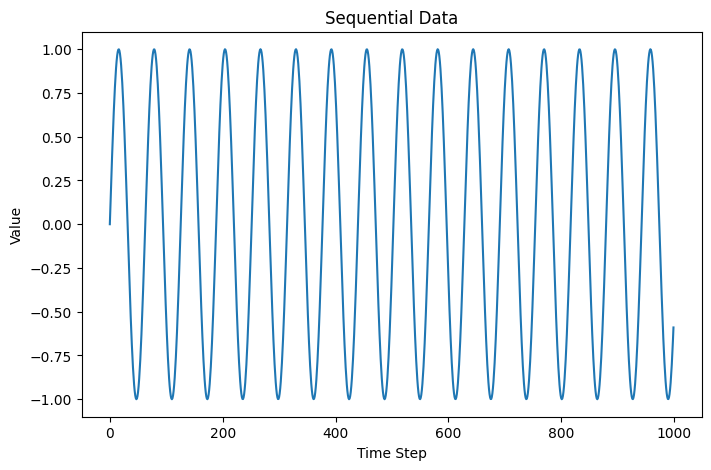

In [2]:
x = np.arange(0, 100, 0.1)
y = np.sin(x)

plt.figure(figsize=(8,5))
plt.plot(y)
plt.title("Sequential Data")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.show()

In [3]:
scaler = MinMaxScaler()

y_scaled = scaler.fit_transform(
    y.reshape(-1,1)
)

X = []
Y = []

window = 10

for i in range(len(y_scaled)-window):
    X.append(y_scaled[i:i+window])
    Y.append(y_scaled[i+window])

X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

(990, 10, 1)
(990, 1)


In [4]:
model = Sequential()

model.add(
    SimpleRNN(
        20,
        activation='tanh',
        input_shape=(window,1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

/Users/vikasshukla/.pyenv/versions/3.11.6/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
history = model.fit(
    X,
    Y,
    epochs=20,
    verbose=1
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step - loss: 0.5836 
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 0.0679
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - loss: 0.0167
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - loss: 0.0077
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step - loss: 0.0053
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - loss: 0.0051
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - loss: 0.0041
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - loss: 0.0034
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - loss: 0.0029
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 430us/step - loss: 0.0024
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step - loss: 0.0020
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - loss: 0.0017
Epoch 13/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - loss: 0.0015
Epoch 14/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step - loss: 0.0013
Epoch 15/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step - l

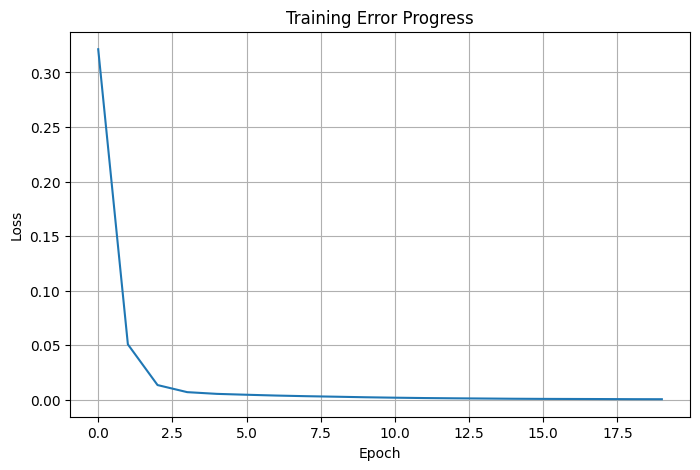

In [6]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])

plt.title("Training Error Progress")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


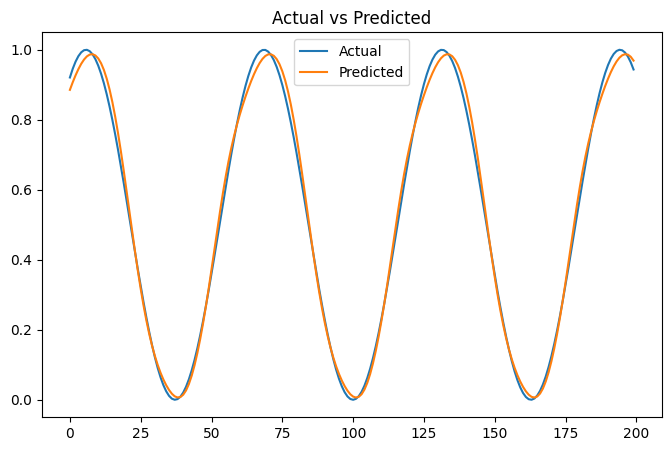

In [7]:
predictions = model.predict(X)

plt.figure(figsize=(8,5))

plt.plot(
    Y[:200],
    label='Actual'
)

plt.plot(
    predictions[:200],
    label='Predicted'
)

plt.legend()

plt.title("Actual vs Predicted")
plt.show()